In [1]:
!pip install odfpy scikit-learn pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160673 sha256=c5973a4ab1f2c0fddfbf0483eb7401326dc5854888ed1595e8d94a5425eb16cb
  Stored in directory: /root/.cache/pip/wheels/36/5d/63/8243a7ee78fff0f944d638fd0e66d7278888f5e2285d7346b6
Successfully built odfpy


In [2]:
from google.colab import files
uploaded = files.upload()

Saving 42_vehicle_gps.ods to 42_vehicle_gps.ods


In [3]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2, degrees
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# STEP 1 — LOAD DATA
# ─────────────────────────────────────────────────────────────
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename, engine="odf")

print("=" * 60)
print("STEP 1 — ORIGINAL DATASET")
print("=" * 60)
print(f"Shape       : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")
print(f"Nulls       : {df.isnull().sum().sum()}")
print(f"Negative speeds: {(df['raw_speed_kmh'] < 0).sum()}")
print(df.head(3))

# ─────────────────────────────────────────────────────────────
# STEP 2 — MISSING FEATURES
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2 — MISSING FEATURES")
print("=" * 60)

missing = {
    "datetime / timestamp":   "Real GPS always has a timestamp. Yahan sirf integer timestep hai.",
    "heading / direction":    "Vehicle kis direction mein ja raha hai (0-360). Missing.",
    "acceleration":           "Speed change per second — braking/acceleration detect karta hai.",
    "distance_per_step":      "Consecutive points ke beech actual distance (meters).",
    "cumulative_distance_km": "Total kitna safar hua — trip summary ke liye zaroori.",
    "altitude":               "GPS mein hamesha altitude hoti hai. Bilkul missing.",
    "gps_accuracy / HDOP":    "GPS fix ki quality — kitna bharosa karein signal pe.",
    "satellite_count":        "Kitne satellites se fix tha — reliability indicator.",
    "vehicle_id":             "Ek se zyada vehicle track karne ke liye chahiye.",
    "road_type":              "Highway vs city road — speed error pattern alag hota hai.",
    "weather":                "Rain/fog mein GPS noise zyada hoti hai.",
    "engine_status":          "On/Off — parked vs moving distinguish karna.",
    "rpm / fuel":             "OBD data — real telematics mein hota hai.",
}

for feature, reason in missing.items():
    print(f"  X {feature}")
    print(f"      -> {reason}")

# ─────────────────────────────────────────────────────────────
# STEP 3 — FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3 — FEATURE ENGINEERING")
print("=" * 60)

# 3a. Datetime
df['datetime'] = pd.to_datetime('2024-01-01') + pd.to_timedelta(df['timestep'], unit='s')

# 3b. Haversine distance
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlam/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

dist_list = [0.0]
for i in range(1, len(df)):
    d = haversine_m(df['latitude'].iloc[i-1], df['longitude'].iloc[i-1],
                    df['latitude'].iloc[i],   df['longitude'].iloc[i])
    dist_list.append(d)

df['dist_m']             = dist_list
df['cumulative_dist_km'] = df['dist_m'].cumsum() / 1000

# 3c. Heading
def bearing(lat1, lon1, lat2, lon2):
    lat1, lat2 = radians(lat1), radians(lat2)
    dlon = radians(lon2 - lon1)
    x = sin(dlon) * cos(lat2)
    y = cos(lat1)*sin(lat2) - sin(lat1)*cos(lat2)*cos(dlon)
    return (degrees(atan2(x, y)) + 360) % 360

bearing_list = [np.nan]
for i in range(1, len(df)):
    bearing_list.append(bearing(
        df['latitude'].iloc[i-1], df['longitude'].iloc[i-1],
        df['latitude'].iloc[i],   df['longitude'].iloc[i]))
df['heading_deg'] = bearing_list

# 3d. Acceleration
df['speed_ms']     = df['true_speed_kmh'] / 3.6
df['acceleration'] = df['speed_ms'].diff()

# 3e. Speed noise
df['speed_noise'] = df['raw_speed_kmh'] - df['true_speed_kmh']

# 3f. Clipped raw speed
df['raw_clipped'] = df['raw_speed_kmh'].clip(lower=0)

# 3g. Lag features
df['raw_lag1']     = df['raw_speed_kmh'].shift(1)
df['raw_lag2']     = df['raw_speed_kmh'].shift(2)
df['raw_rolling3'] = df['raw_speed_kmh'].rolling(3, min_periods=1).mean()

# 3h. Motion state
def motion_state(s):
    if s < 2:    return 'parked'
    elif s < 30: return 'slow'
    elif s < 80: return 'medium'
    else:        return 'highway'

df['motion_state'] = df['true_speed_kmh'].apply(motion_state)

print("Engineered features:")
for c in ['datetime','dist_m','cumulative_dist_km','heading_deg',
          'acceleration','speed_noise','raw_clipped',
          'raw_lag1','raw_lag2','raw_rolling3','motion_state']:
    print(f"  + {c}")

print(f"\nNew shape: {df.shape}")
print(df[['timestep','true_speed_kmh','heading_deg',
          'acceleration','dist_m','motion_state']].head())

# ─────────────────────────────────────────────────────────────
# STEP 4 — DATA QUALITY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4 — DATA QUALITY TRAPS")
print("=" * 60)

neg_count = (df['raw_speed_kmh'] < 0).sum()
cap_count = (df['true_speed_kmh'] >= 130).sum()
raw_over  = (df['raw_speed_kmh'] > 130).sum()

print(f"  Negative raw speeds  : {neg_count} rows ({100*neg_count/len(df):.1f}%)")
print(f"  True speed at cap    : {cap_count} rows")
print(f"  Raw speed > 130      : {raw_over} rows")
print(f"  Total distance       : {df['cumulative_dist_km'].iloc[-1]:.2f} km")
print(f"\nMotion state distribution:")
print(df['motion_state'].value_counts())

# ─────────────────────────────────────────────────────────────
# STEP 5 — MODEL COMPARISON
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5 — MODEL COMPARISON")
print("=" * 60)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

feature_cols = ['raw_speed_kmh', 'raw_clipped', 'raw_lag1', 'raw_lag2', 'raw_rolling3']
df_model = df.dropna(subset=feature_cols + ['true_speed_kmh'])
X = df_model[feature_cols]
y = df_model['true_speed_kmh']

tscv = TimeSeriesSplit(n_splits=5)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (a=1)':       Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

naive_rmse = np.sqrt(mean_squared_error(y, df_model['raw_clipped']))
print(f"  Naive baseline RMSE: {naive_rmse:.4f}")
print(f"\n  {'Model':<22} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print("  " + "-" * 50)

best_model, best_rmse = None, 999
for name, model in models.items():
    rmse = np.sqrt(-cross_val_score(model, X, y, cv=tscv,
                   scoring='neg_mean_squared_error')).mean()
    mae  = (-cross_val_score(model, X, y, cv=tscv,
                   scoring='neg_mean_absolute_error')).mean()
    r2   = cross_val_score(model, X, y, cv=tscv, scoring='r2').mean()
    note = "<-- BEST" if rmse < best_rmse else ""
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = (name, model)
    print(f"  {name:<22} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}  {note}")

# ─────────────────────────────────────────────────────────────
# STEP 6 — TRAIN BEST MODEL
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"STEP 6 — BEST MODEL: {best_model[0]}")
print("=" * 60)

model = best_model[1]
model.fit(X, y)
y_pred    = model.predict(X)
residuals = y - y_pred

print(f"  RMSE        : {np.sqrt(mean_squared_error(y, y_pred)):.4f} kmh")
print(f"  MAE         : {mean_absolute_error(y, y_pred):.4f} kmh")
print(f"  R2          : {r2_score(y, y_pred):.4f}")
print(f"  Residual std: {residuals.std():.4f}")
print(f"  Error > 5   : {(residuals.abs() > 5).sum()} rows")

if hasattr(model, 'coef_'):
    print("\n  Coefficients:")
    for feat, coef in zip(feature_cols, model.coef_):
        print(f"    {feat:<20}: {coef:.4f}")

# ─────────────────────────────────────────────────────────────
# STEP 7 — SAVE ENRICHED CSV
# ─────────────────────────────────────────────────────────────
df['predicted_speed']  = model.predict(df[feature_cols].bfill())
df['prediction_error'] = df['true_speed_kmh'] - df['predicted_speed']

df.to_csv("vehicle_gps_enriched.csv", index=False)
print("\nSaved: vehicle_gps_enriched.csv")
print(f"Final shape: {df.shape}")
print("\nDone!")

STEP 1 — ORIGINAL DATASET
Shape       : (1500, 5)
Columns     : ['timestep', 'latitude', 'longitude', 'raw_speed_kmh', 'true_speed_kmh']
Nulls       : 0
Negative speeds: 16
   timestep  latitude  longitude  raw_speed_kmh  true_speed_kmh
0         1  28.60000   77.20000          -1.92            0.00
1         2  28.60005   77.20007           2.43            1.45
2         3  28.60010   77.20014           2.75            3.91

STEP 2 — MISSING FEATURES
  X datetime / timestamp
      -> Real GPS always has a timestamp. Yahan sirf integer timestep hai.
  X heading / direction
      -> Vehicle kis direction mein ja raha hai (0-360). Missing.
  X acceleration
      -> Speed change per second — braking/acceleration detect karta hai.
  X distance_per_step
      -> Consecutive points ke beech actual distance (meters).
  X cumulative_distance_km
      -> Total kitna safar hua — trip summary ke liye zaroori.
  X altitude
      -> GPS mein hamesha altitude hoti hai. Bilkul missing.
  X gps_accura

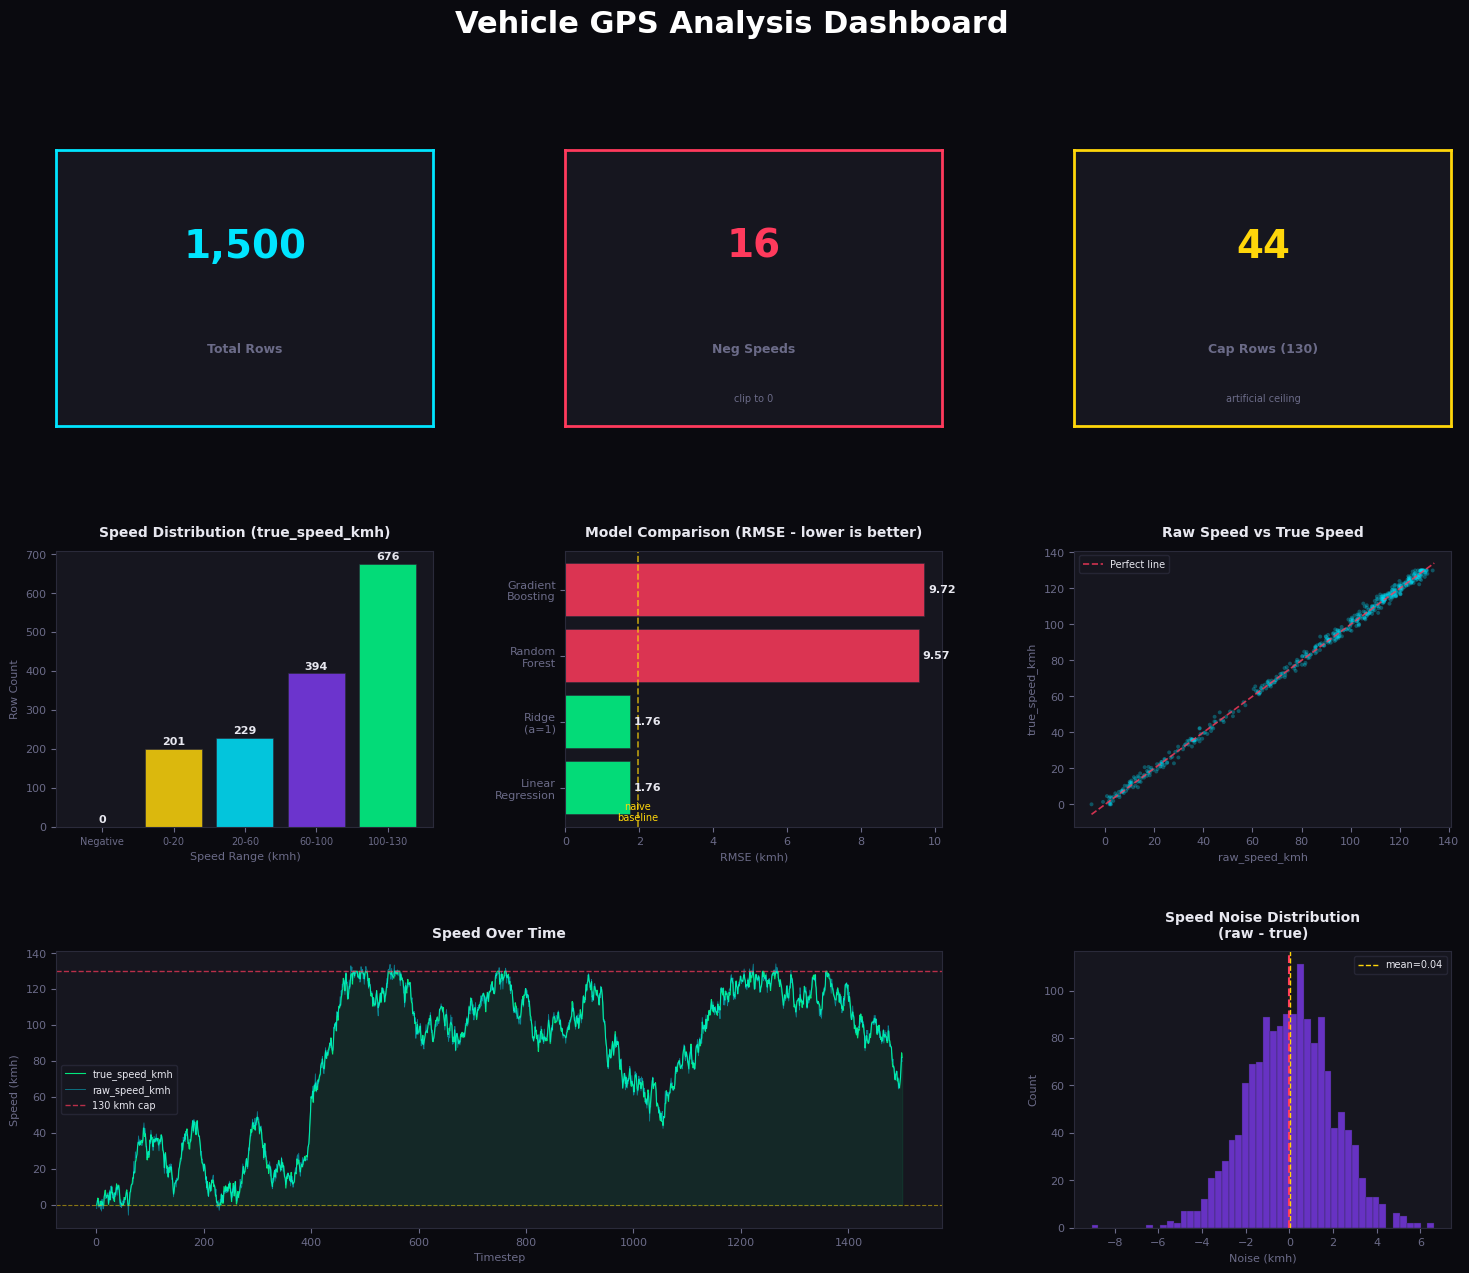

Chart saved as gps_dashboard.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 14), facecolor='#0a0a0f')
fig.suptitle('Vehicle GPS Analysis Dashboard',
             fontsize=22, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── COLOR PALETTE ──────────────────────────────────────────
BG      = '#0a0a0f'
CARD    = '#16161f'
ACCENT  = '#00e5ff'
GREEN   = '#00ff88'
RED     = '#ff3a5c'
YELLOW  = '#ffd60a'
PURPLE  = '#7c3aed'
ORANGE  = '#ff6b35'
MUTED   = '#6b6b88'
WHITE   = '#e8e8f0'

def styled_ax(ax, title=''):
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_color('#2a2a3a')
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    if title:
        ax.set_title(title, color=WHITE, fontsize=10,
                     fontweight='bold', pad=10)
    return ax

# ── CHART 1: METRIC CARDS (top row) ────────────────────────
metrics = [
    ('Total Rows',      f"{len(df):,}",     ACCENT,  ''),
    ('Neg Speeds',      str((df['raw_speed_kmh']<0).sum()), RED, 'clip to 0'),
    ('Cap Rows (130)',  str((df['true_speed_kmh']>=130).sum()), YELLOW, 'artificial ceiling'),
]

for idx, (label, value, color, sub) in enumerate(metrics):
    ax = fig.add_subplot(gs[0, idx])
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.65, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=28,
            fontweight='bold', color=color)
    ax.text(0.5, 0.28, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=9,
            color=MUTED, fontweight='bold')
    if sub:
        ax.text(0.5, 0.1, sub, transform=ax.transAxes,
                ha='center', va='center', fontsize=7, color=MUTED)

# ── CHART 2: SPEED DISTRIBUTION BAR ────────────────────────
ax2 = styled_ax(fig.add_subplot(gs[1, 0]), 'Speed Distribution (true_speed_kmh)')

buckets = ['Negative', '0-20', '20-60', '60-100', '100-130']
counts  = [
    (df['true_speed_kmh'] < 0).sum(),
    ((df['true_speed_kmh'] >= 0)  & (df['true_speed_kmh'] < 20)).sum(),
    ((df['true_speed_kmh'] >= 20) & (df['true_speed_kmh'] < 60)).sum(),
    ((df['true_speed_kmh'] >= 60) & (df['true_speed_kmh'] < 100)).sum(),
    (df['true_speed_kmh'] >= 100).sum(),
]
colors_bar = [RED, YELLOW, ACCENT, PURPLE, GREEN]
bars = ax2.bar(buckets, counts, color=colors_bar, alpha=0.85,
               edgecolor='#2a2a3a', linewidth=0.5)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom',
             color=WHITE, fontsize=8, fontweight='bold')
ax2.set_xlabel('Speed Range (kmh)', fontsize=8)
ax2.set_ylabel('Row Count', fontsize=8)
ax2.tick_params(axis='x', labelsize=7)

# ── CHART 3: MODEL COMPARISON ───────────────────────────────
ax3 = styled_ax(fig.add_subplot(gs[1, 1]), 'Model Comparison (RMSE - lower is better)')

model_names  = ['Linear\nRegression', 'Ridge\n(a=1)', 'Random\nForest', 'Gradient\nBoosting']
model_rmses  = [1.76, 1.76, 9.57, 9.72]
model_colors = [GREEN, GREEN, RED, RED]

bars2 = ax3.barh(model_names, model_rmses, color=model_colors,
                 alpha=0.85, edgecolor='#2a2a3a', linewidth=0.5)
for bar, rmse in zip(bars2, model_rmses):
    ax3.text(rmse + 0.1, bar.get_y() + bar.get_height()/2,
             f'{rmse}', va='center', color=WHITE, fontsize=8, fontweight='bold')
ax3.axvline(x=1.96, color=YELLOW, linestyle='--', linewidth=1.2, alpha=0.7)
ax3.text(1.96, -0.5, 'naive\nbaseline', color=YELLOW, fontsize=7, ha='center')
ax3.set_xlabel('RMSE (kmh)', fontsize=8)

# ── CHART 4: RAW vs TRUE SPEED SCATTER ──────────────────────
ax4 = styled_ax(fig.add_subplot(gs[1, 2]), 'Raw Speed vs True Speed')

sample = df.sample(min(500, len(df)), random_state=42)
ax4.scatter(sample['raw_speed_kmh'], sample['true_speed_kmh'],
            c=ACCENT, alpha=0.3, s=8, edgecolors='none')
min_val = min(df['raw_speed_kmh'].min(), df['true_speed_kmh'].min())
max_val = max(df['raw_speed_kmh'].max(), df['true_speed_kmh'].max())
ax4.plot([min_val, max_val], [min_val, max_val],
         color=RED, linewidth=1.2, linestyle='--', alpha=0.8, label='Perfect line')
ax4.set_xlabel('raw_speed_kmh', fontsize=8)
ax4.set_ylabel('true_speed_kmh', fontsize=8)
ax4.legend(fontsize=7, facecolor=CARD, edgecolor='#2a2a3a',
           labelcolor=WHITE)

# ── CHART 5: SPEED OVER TIME ────────────────────────────────
ax5 = styled_ax(fig.add_subplot(gs[2, :2]), 'Speed Over Time')

ax5.plot(df['timestep'], df['true_speed_kmh'],
         color=GREEN, linewidth=0.8, alpha=0.9, label='true_speed_kmh')
ax5.plot(df['timestep'], df['raw_speed_kmh'],
         color=ACCENT, linewidth=0.6, alpha=0.5, label='raw_speed_kmh')
ax5.axhline(y=130, color=RED, linestyle='--', linewidth=1,
            alpha=0.7, label='130 kmh cap')
ax5.axhline(y=0, color=YELLOW, linestyle='--', linewidth=0.8, alpha=0.5)
ax5.fill_between(df['timestep'],
                 df['true_speed_kmh'], 0,
                 alpha=0.08, color=GREEN)
ax5.set_xlabel('Timestep', fontsize=8)
ax5.set_ylabel('Speed (kmh)', fontsize=8)
ax5.legend(fontsize=7, facecolor=CARD,
           edgecolor='#2a2a3a', labelcolor=WHITE)

# ── CHART 6: RESIDUALS DISTRIBUTION ─────────────────────────
ax6 = styled_ax(fig.add_subplot(gs[2, 2]), 'Speed Noise Distribution\n(raw - true)')

noise = df['speed_noise'].dropna()
ax6.hist(noise, bins=50, color=PURPLE, alpha=0.8,
         edgecolor='#2a2a3a', linewidth=0.3)
ax6.axvline(x=0, color=RED, linewidth=1.5, linestyle='--')
ax6.axvline(x=noise.mean(), color=YELLOW, linewidth=1,
            linestyle='--', label=f'mean={noise.mean():.2f}')
ax6.set_xlabel('Noise (kmh)', fontsize=8)
ax6.set_ylabel('Count', fontsize=8)
ax6.legend(fontsize=7, facecolor=CARD,
           edgecolor='#2a2a3a', labelcolor=WHITE)

plt.savefig('gps_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Chart saved as gps_dashboard.png")